In [1]:
# implement a backtesting engine that takes in 1 csv containing columns datetime,open,high,low,close,volume 
# and another csv containing the same columns but with the strategy's buy/sell signals added and returns
# multiple performance metrics and the graph

'''
Static
performance metrics to calculate:-
1. total trades
2. winning trades
3. losing trades
4. benchmark return (buy and hold)
5. win rate
6. gross profit
7. net profit
8. average profit 
9. maxiumum drawdown (percentage)
10. largest win
11. average win
12. largest loss
13. average loss
14. max holding period
15. average holding period
16. max dip
17. average dip
18. sharpe ratio
19. sortino ratio
20. from and to dates

Compounding
performance metrics to calculate:-
1. Initial Balance
2. Number of trades
3. Max PNL
4. Min PNL
5. Peak Portfolio Balance
6. Lowest Portfolio Balance
7. End Portfolio Balance
8. Total Fee
'''


'\nStatic\nperformance metrics to calculate:-\n1. total trades\n2. winning trades\n3. losing trades\n4. benchmark return (buy and hold)\n5. win rate\n6. gross profit\n7. net profit\n8. average profit \n9. maxiumum drawdown (percentage)\n10. largest win\n11. average win\n12. largest loss\n13. average loss\n14. max holding period\n15. average holding period\n16. max dip\n17. average dip\n18. sharpe ratio\n19. sortino ratio\n20. from and to dates\n\nCompounding\nperformance metrics to calculate:-\n1. Initial Balance\n2. Number of trades\n3. Max PNL\n4. Min PNL\n5. Peak Portfolio Balance\n6. Lowest Portfolio Balance\n7. End Portfolio Balance\n8. Total Fee\n'

In [2]:
#import both csvs:- 1. historical data 2. strategy signals
import backtesting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import math
from datetime import datetime

#read csvs
#historical data
hist = pd.read_csv('btcusdt_1h.csv')
strat = pd.read_csv('submission7.csv')

#format of hist
#datetime,open,high,low,close,volume

#format of strat
#datetime,signals,open,high,low,close,volume,


# 1. open long
class backtest():
    def __init__(self, hist, strat):
        self.is_static = True
        self.trade_signal = 0
        self.hist = hist
        self.strat = strat
        self.signals = self.extract_signals()
        self.capital = 1000 # fixed capital in static   #constant        
        self.total_portfolio_static = 1000
        self.pnl = []
        self.total_portfolio_compound = 1000
        self.static_balance = []
        self.compound_balance = []
        #self.hist['compound_balance'] = self.compound_balance
        self.total_pnl = 0 #compounding
        self.total_pnl_cumm = []
        self.number_of_btc=0
        self.fee = 0.0015
        self.trades = 0
        self.win_trades = 0
        self.lose_trades = 0
        self.benchmark = 0
        self.win_rate = 0
        self.gross_profit = 0
        self.net_profit = 0
        self.avg_profit = 0
        self.max_drawdown = 0
        self.largest_win = 0
        self.avg_win = 0
        self.largest_loss = 0
        self.avg_loss = 0
        self.max_holding_period = 0
        self.avg_holding_period = 0
        self.max_dip = 0
        self.avg_dip = 0
        self.sharpe_ratio = 0
        self.sortino_ratio = 0
        self.is_closed = True
        self.initial_price = 0
        self.final_price = 0
        #extract to and from datetime
        self.from_datetime = self.hist['datetime'][0]
        self.to_datetime = self.hist['datetime'][len(self.hist)-1]
        self.entry_times = []
        self.exit_times = []
        self.dips = []
        self.multiple = False
        self.total_compound_fee = 0

    # 5 cases:-
    # 1. open long
    # 2. close long
    # 3. open short
    # 4. close short
    # 5. do nothing

    def extract_signals(self):
        #extract signals from strat
        signals = self.strat['signals']
        return signals
    
    def transaction_cost(self, price):
        return self.fee*price
    
    def open_long(self, index):
        #buy at opening price
        self.initial_price = self.hist['close'][index]
        self.is_closed = False
        self.trade_signal = 1
        self.entry_times.append(self.hist['datetime'][index])
        #static
        if self.is_static:
            self.total_portfolio_static -= self.transaction_cost(self.capital)
            self.static_balance.append(self.total_portfolio_static)
            self.total_portfolio_static -= self.capital
            self.number_of_btc += self.capital/self.hist['close'][index]
        #compounding
        else:
            self.number_of_btc += self.total_portfolio_compound/self.hist['close'][index]
            curr_transaction_cost = self.transaction_cost(self.total_portfolio_compound)
            self.total_compound_fee += curr_transaction_cost
            self.total_portfolio_compound = 0
            self.total_portfolio_compound -= curr_transaction_cost
    

    def open_short(self, index):
        #sell at closing price
        self.initial_price = self.hist['close'][index]
        self.is_closed = False
        self.entry_times.append(self.hist['datetime'][index])
        self.trade_signal = -1
        #static
        if self.is_static:
            self.number_of_btc -= self.capital/self.hist['close'][index]
            self.total_portfolio_static -= self.transaction_cost(self.capital)
            self.static_balance.append(self.total_portfolio_static)
            self.total_portfolio_static += self.capital
        #compounding
        else:
            self.number_of_btc -= self.total_portfolio_compound/self.hist['close'][index]
            self.total_portfolio_compound -= self.transaction_cost(self.total_portfolio_compound)
            self.total_compound_fee += self.transaction_cost(self.total_portfolio_compound)
            self.total_portfolio_compound += (-self.number_of_btc)*self.hist['close'][index]
             


    def close_long(self, index):
        #sell at closing price
        self.final_price = self.hist['close'][index]
        self.is_closed = True
        self.trades += 1
        current_pnl = self.number_of_btc*(self.final_price-self.initial_price)
        if self.is_static:
            current_pnl -= self.transaction_cost(self.capital)
        else:
            current_pnl -= self.transaction_cost(self.total_portfolio_compound)
        self.total_pnl += current_pnl
        self.total_pnl_cumm.append(self.total_pnl)
        self.pnl.append(current_pnl)
        self.trade_signal = 0
        self.exit_times.append(self.hist['datetime'][index])
        if current_pnl < 0 :
            dip = -((self.final_price - self.initial_price)/self.initial_price)
            self.dips.append(dip)
        #static
        if self.is_static:
            self.total_portfolio_static += self.number_of_btc*self.hist['close'][index]
            self.static_balance.append(self.total_portfolio_static)
            self.number_of_btc = 0
        #compounding
        else:
            self.total_portfolio_compound += self.number_of_btc*self.hist['close'][index]
            self.compound_balance.append(self.total_portfolio_compound) 
            self.number_of_btc = 0


    def close_short(self, index):
        #buy at open      
        self.final_price = self.hist['close'][index]
        self.is_closed = True
        self.trades += 1
        current_pnl = (-self.number_of_btc)*(self.initial_price-self.final_price)
        if self.is_static:
            current_pnl -= self.transaction_cost(self.capital)
        else:
            current_pnl -= self.transaction_cost(self.total_portfolio_compound)
        self.total_pnl += current_pnl
        self.total_pnl_cumm.append(self.total_pnl)
        self.pnl.append(current_pnl)
        self.trade_signal = 0
        self.exit_times.append(self.hist['datetime'][index])
        
        if current_pnl < 0 :
            dip = ((self.final_price - self.initial_price)/self.initial_price)
            self.dips.append(dip)
        #static
        if self.is_static:
            self.total_portfolio_static += (self.number_of_btc)*self.hist['close'][index]
            self.static_balance.append(self.total_portfolio_static)
            self.number_of_btc = 0
        #compounding
        else:
            self.total_portfolio_compound += (self.number_of_btc)*self.hist['close'][index]
            self.compound_balance.append(self.total_portfolio_compound)
            self.number_of_btc = 0 

    def do_nothing(self, index):
        #evil floating point bit hack
        self.static_balance.append(self.total_portfolio_static+self.number_of_btc*self.hist['close'][index])
        pass
    
    #plot graph of compound balance vs time 
    def plot_graph(self):
        # x axis is datetime
        # y axis is compound balance
        # plot compound balance vs time
        plt.plot(self.compound_balance)
        plt.xlabel('No of Trades')
        plt.ylabel('compound balance')
        plt.show()
   
    def calculate_net_profit(self):
        self.net_profit = sum(pnl for pnl in self.pnl)

    def calculate_max_drawdown(self):
    #calculate max_drawdown perc using static balance
        stat_balance = self.static_balance
        static_balance_series = pd.Series(stat_balance)
        max_balance = static_balance_series.cummax()
        drawdown = (static_balance_series - max_balance)
        max_drawdown_index = drawdown.idxmin()
        max_drawdown = (drawdown[max_drawdown_index]/max_balance[max_drawdown_index])*100
        self.max_drawdown = max_drawdown


        
    def calculate_holding_periods(self):
    # Assuming you have a list of timestamps representing entry and exit times
        entry_times = [datetime.strptime(time_str, '%Y-%m-%d %H:%M:%S') for time_str in self.entry_times]
        exit_times = [datetime.strptime(time_str, '%Y-%m-%d %H:%M:%S') for time_str in self.exit_times]

    # Calculate the holding period for each trade
        holding_periods = [(exit_time - entry_time).total_seconds() / 3600 for entry_time, exit_time in zip(entry_times, exit_times)]

        if holding_periods:
            self.max_holding_period = max(holding_periods)
            self.avg_holding_period = sum(holding_periods) / len(holding_periods)
        else:
            self.max_holding_period = 0
            self.avg_holding_period = 0

    def calculate_benchmark(self):
        self.benchmark = ((self.hist['close'][len(self.hist) - 1]-self.hist['close'][0])/self.hist['close'][0])*self.capital
    
    def calculate_ratios(self):
        #for sharpe ratio, find return of portfolio and subtract risk free rate, then divide by standard deviation of portfolio
        #for sortino ratio, find return of portfolio and subtract risk free rate, then divide by standard deviation of negative returns
        
    
        # Calculate Sharpe ratio
        returns = pd.DataFrame(self.pnl)
        avg_return = returns.mean()
        risk_free_rate = 0.02
        std_dev = returns.std()
        self.sharpe_ratio = (avg_return - risk_free_rate) / std_dev

        # Calculate Sortino ratio
        downside_returns = returns[returns < 0]
        avg_downside_return = downside_returns.mean()
        downside_std_dev = downside_returns.std()
        self.sortino_ratio = (avg_downside_return - risk_free_rate) / downside_std_dev
        
        self.sharpe_ratio = self.sharpe_ratio.tolist()[0]
        self.sortino_ratio = self.sortino_ratio.tolist()[0]


        
    def calculate_metrics_static(self):
        # Calculate static performance metrics
        self.total_trades_static = self.trades
        self.win_trades_static = sum(pnl > -(self.capital*self.fee) for pnl in self.pnl)
        self.lose_trades_static = self.total_trades_static - self.win_trades_static
        self.win_rate_static = self.win_trades_static / self.total_trades_static if self.total_trades_static > 0 else 0
        self.calculate_net_profit()
        self.gross_profit = self.net_profit + self.trades*self.capital*self.fee
        self.avg_profit_static = self.net_profit / (self.trades)
        self.largest_win = max(self.pnl)
        self.largest_loss = min(self.pnl)
        self.avg_win_static = (sum(pnl for pnl in self.pnl if pnl > 0)//self.win_trades_static) if self.win_trades_static > 0 else 0
        self.avg_loss_static = (sum(pnl for pnl in self.pnl if pnl < 0)//self.lose_trades_static) if self.lose_trades_static > 0 else 0
        self.calculate_max_drawdown()
        self.calculate_holding_periods()
        self.calculate_benchmark()
        self.calculate_ratios()
        self.max_dip = max(self.dips)
        self.avg_dip = sum(self.dips)/len(self.dips)

    def calculate_metrics_compound(self):
        # Calculate compound performance metrics
        self.initial_balance_compound = self.capital
        self.num_trades_compound = self.trades
        self.max_pnl_compound = max(self.pnl) 
        self.min_pnl_compound = min(self.pnl)
        self.peak_portfolio_balance_compound = max(self.compound_balance) if self.compound_balance else self.initial_balance_compound
        self.lowest_portfolio_balance_compound = min(self.compound_balance) 
        self.end_portfolio_balance_compound = self.compound_balance[-1] if self.compound_balance else self.initial_balance_compound
        

    
    def backtest(self, static,multiple):
        self.multiple = multiple
        if self.multiple == False:
            self.is_static = static
            for index, signal in enumerate(self.signals):
                if signal == 1 and self.is_closed:
                    self.open_long(index)
                elif signal == -1 and not self.is_closed:
                    self.close_long(index)
                elif signal == -1 and self.is_closed:
                    self.open_short(index)
                elif signal == 1 and not self.is_closed:
                    self.close_short(index)
                else:
                    self.do_nothing(index)
            
            if not self.is_static:
                self.plot_graph()
                self.calculate_metrics_compound()
            else:    
                self.calculate_metrics_static()
        else:
            self.is_static = static
            for index, signal in enumerate(self.signals):
                if signal == 1 :
                    if self.trade_signal == 1:
                        self.close_long(index)
                    elif self.trade_signal == -1: 
                        self.close_short(index)
                    self.open_long(index)
                elif signal == -1 :
                    if self.trade_signal == 1:
                        self.close_long(index)
                    elif self.trade_signal == -1: 
                        self.close_short(index)
                    self.open_short(index)
                else:
                    self.do_nothing(index)
                    
            if not self.is_static:
                self.plot_graph()
                self.calculate_metrics_compound()
            else:    
                self.calculate_metrics_static()
        

# Multiple = False

35208
Total Trades (Static): 493
Winning Trades (Static): 163
Losing Trades (Static): 330
Win Rate (Static): 0.3306288032454361
Gross Profit (Static): 4443.118747491752
Net Profit (Static): 3703.6187474917524
Average Profit (Static): 7.512411252518768
Largest Win (Static): 537.3105075546434
Largest Loss (Static): -107.86140851794464
Average Win (Static): 69.0
Average Loss (Static): -24.0
Max Drawdown (Static): -19.12666122955022
Max Holding Period (Static): 498.0
Average Holding Period (Static): 70.60446247464503
Max Dip (Static): 10.636140851794465 %
Average Dip (Static): 2.1080347408119016 %
Sharpe Ratio (Static): 0.10832190512684024
Sortino Ratio (Static): -1.4064048528975088
Benchmark: 2154.3328004044643
Compared to Benchmark: 1549.2859470872882


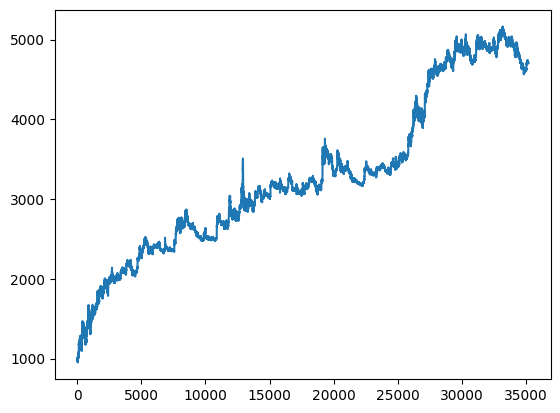

In [3]:
# Create a backtest object
bt = backtest(hist, strat)

# Run the backtest in static mode
bt.backtest(static=True,multiple = False)
#plot static balance vs time
plt.plot(bt.static_balance)
print(len(bt.static_balance))
# Print the calculated metrics
print("Total Trades (Static):", bt.total_trades_static)
print("Winning Trades (Static):", bt.win_trades_static)
print("Losing Trades (Static):", bt.lose_trades_static)
print("Win Rate (Static):", bt.win_rate_static)
print("Gross Profit (Static):", bt.gross_profit)
print("Net Profit (Static):", bt.net_profit)
print("Average Profit (Static):", bt.avg_profit_static)
print("Largest Win (Static):", bt.largest_win)
print("Largest Loss (Static):", bt.largest_loss)
print("Average Win (Static):", bt.avg_win_static)
print("Average Loss (Static):", bt.avg_loss_static)
print("Max Drawdown (Static):", bt.max_drawdown)
print("Max Holding Period (Static):", bt.max_holding_period)
print("Average Holding Period (Static):", bt.avg_holding_period)
print("Max Dip (Static):", bt.max_dip*100,"%")
print("Average Dip (Static):", bt.avg_dip*100,"%")
print("Sharpe Ratio (Static):", bt.sharpe_ratio)
print("Sortino Ratio (Static):", bt.sortino_ratio)
print("Benchmark:", bt.benchmark)
print("Compared to Benchmark:",bt.net_profit-bt.benchmark)







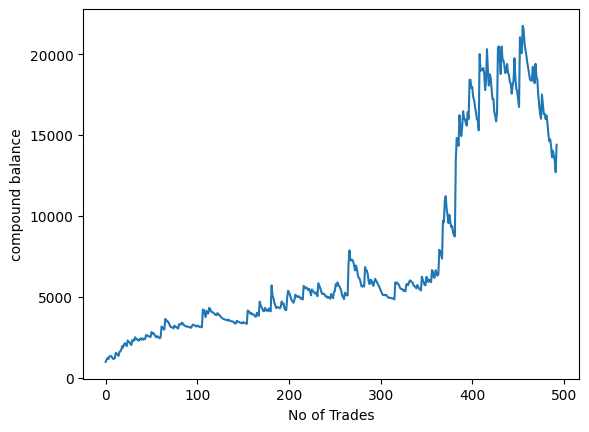

[1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 17.286932890465778, 16.98497773080703, 8.454744470446144, 0.500490677134394, -11.492413376613513, -17.665131727938387, -15.47520193251296, -10.040009058654732, -37.97161621499208, -26.647542839888274, -20.759417226541814, -8.060692987091443, 9.03525326489023, 6.042877632671548, -0.6778893334338818, -7.246923831810932, -5.970408394353399, -15.47520193251296, -23.627991243300357, -18.343775949271503, -18.271306710953468, -46.650562391484755, 1959.926804079123, 1973.3459818462602, 2029.853731155187, 2040.64317953886, 2041.93226256997, 2037.7930699330911, 2045.3905368276762, 2036.571796201152, 2043.594296746519, 2046.806055947865, 2060.0903214635273, 2046.6993975710443, 2060.9089774816402, 2058.6726833027396, 2076.658393560904, 2071.5281962705203, 2059.703243380761, 2025.6149436101512, 2021.063244403317, 2040.4524658849425, 2020.6712218924863, 2049.279682673863, 2044.694

In [4]:
# Create a backtest object
bt = backtest(hist, strat)

# Run the backtest in static mode
bt.backtest(static=False,multiple=False)
print(bt.static_balance)
# Print the calculated metrics
print("Initial Balance (Compound):", bt.initial_balance_compound)
print("Number of Trades (Compound):", bt.num_trades_compound)
print("Maximum PnL (Compound):", bt.max_pnl_compound)
print("Minimum PnL (Compound):", bt.min_pnl_compound)
print("Peak Portfolio Balance (Compound):", bt.peak_portfolio_balance_compound)
print("Lowest Portfolio Balance (Compound):", bt.lowest_portfolio_balance_compound)
print("End Portfolio Balance (Compound):", bt.end_portfolio_balance_compound)
print("Total Fee (Compound):", bt.total_compound_fee)